In [1]:
%load_ext autoreload
import os; os.chdir("..")

In [2]:
import matplotlib.pyplot as plt
from permacache import stable_hash

from orthogonal_dfa.analysis.nonlinear_motif_miner import (
    ScoreOracle,
    marginal_records_until,
)
from orthogonal_dfa.analysis.nonlinear_motif_miner_plot import plot_top_motifs
from orthogonal_dfa.data.exon import default_exon
from orthogonal_dfa.l_star.examples.gate_composition_residual import (
    fit_gate_composition_residual,
)
from orthogonal_dfa.l_star.examples.spliceai_oracle import flanks, run_over_middles
from orthogonal_dfa.spliceai.exon_score import SpliceAIExonScore, device_of
from orthogonal_dfa.spliceai.load_model import load_spliceai

In [3]:
class GateResidualExonScore(ScoreOracle):
    """SpliceAI's exon score minus a per-length-bin monotonic-gate bag-of-k-mers
    prediction, so composition is removed but positional structure is not."""

    alphabet = "ACGT"

    def __init__(self, exon, spliceai_model, *, device=None, chunk=1024, **fit_kw):
        self.exon = exon
        self.chunk = chunk
        self.fit_kw = fit_kw
        self.score_model = SpliceAIExonScore(spliceai_model).eval()
        self.residual = fit_gate_composition_residual(
            self.score_model, exon, device=device, **fit_kw
        )
        self.device = device_of(self.score_model, device)
        self.flank_l, self.flank_r = flanks(exon)

    @property
    def length(self):
        return self.exon.random_text_length

    def scores(self, seqs):
        return run_over_middles(
            self.residual,
            self.flank_l,
            self.flank_r,
            seqs,
            device=self.device,
            chunk=self.chunk,
        )

    def hash_payload(self):
        return [
            stable_hash(self.score_model, version=2),
            stable_hash(self.exon),
            stable_hash(self.fit_kw),
        ]

In [4]:
oracle = GateResidualExonScore(default_exon, load_spliceai(400, 0))

In [5]:
records4, info4 = marginal_records_until(
    oracle, 4, 0.04, contexts_per_round=200, max_contexts=16000
)

  1%|1         | 200/16000 [00:00<00:01, 9399.84ctx/s, bound=0.1608]

In [6]:
print(info4["n_contexts"], "contexts; achieved bound:", round(info4["bound"], 3))

3200 contexts; achieved bound: 0.039


In [7]:
for r in records4[:30]:
    print(r)

TAG [k=3]  marginal=0.2756
GGTA [k=4]  marginal=0.2755
TGA [k=3]  marginal=0.2608
TAA [k=3]  marginal=0.2583
AGGT [k=4]  marginal=0.2467
GTAA [k=4]  marginal=0.2329
TAAG [k=4]  marginal=0.2113
TAGG [k=4]  marginal=0.2072
TA [k=2]  marginal=0.2052
GGT [k=3]  marginal=0.2002
AG [k=2]  marginal=0.1976
AGTA [k=4]  marginal=0.1970
AGG [k=3]  marginal=0.1948
GTAT [k=4]  marginal=0.1923
GTA [k=3]  marginal=0.1914
AAGT [k=4]  marginal=0.1899
AAGG [k=4]  marginal=0.1896
CGGT [k=4]  marginal=0.1893
AAG [k=3]  marginal=0.1871
GATA [k=4]  marginal=0.1852
GATT [k=4]  marginal=0.1841
AGGA [k=4]  marginal=0.1834
TGAG [k=4]  marginal=0.1825
AGGG [k=4]  marginal=0.1809
GTAC [k=4]  marginal=0.1809
GGTT [k=4]  marginal=0.1808
GAAG [k=4]  marginal=0.1795
GGGT [k=4]  marginal=0.1784
T [k=1]  marginal=0.1780
GAGG [k=4]  marginal=0.1777


<Axes: xlabel='marginal effect'>

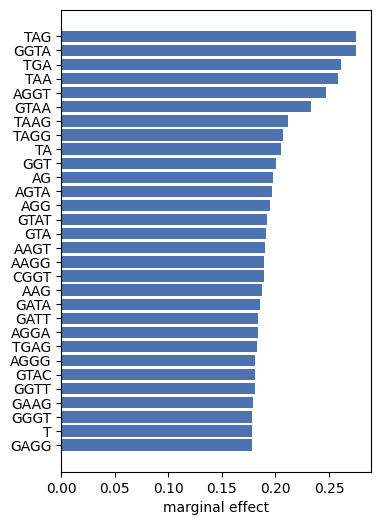

In [8]:
plt.figure(figsize=(4, 6))
plot_top_motifs(records4, top=30)

In [9]:
records, info = marginal_records_until(
    oracle, 6, 0.04, contexts_per_round=200, max_contexts=16000
)

  1%|1         | 200/16000 [00:00<00:01, 10197.68ctx/s, bound=0.3013]

In [10]:
print(info["n_contexts"], "contexts; achieved bound:", round(info["bound"], 3))

8600 contexts; achieved bound: 0.04


In [11]:
for r in records[:30]:
    print(r)

GGTAAG [k=6]  marginal=0.5022
GTAAGT [k=6]  marginal=0.4000
AGGTA [k=5]  marginal=0.3579
GTAAG [k=5]  marginal=0.3529
GGTAGG [k=6]  marginal=0.3517
AGGTAA [k=6]  marginal=0.3411
GGTGAG [k=6]  marginal=0.3407
GTGAGT [k=6]  marginal=0.3347
TAGGTA [k=6]  marginal=0.3213
GGTAA [k=5]  marginal=0.3084
GGTACG [k=6]  marginal=0.2866
GTAGGT [k=6]  marginal=0.2825
AGGTAG [k=6]  marginal=0.2820
GGTATG [k=6]  marginal=0.2815
AGGTGA [k=6]  marginal=0.2802
TAG [k=3]  marginal=0.2774
GGTA [k=4]  marginal=0.2746
GAATAC [k=6]  marginal=0.2644
GAATAT [k=6]  marginal=0.2621
TGA [k=3]  marginal=0.2612
TAA [k=3]  marginal=0.2561
TAAGGT [k=6]  marginal=0.2558
GTGAG [k=5]  marginal=0.2556
GGTGGG [k=6]  marginal=0.2530
AGGT [k=4]  marginal=0.2500
TAGTAG [k=6]  marginal=0.2456
TAGGT [k=5]  marginal=0.2452
TGAGTA [k=6]  marginal=0.2449
GAGGTA [k=6]  marginal=0.2445
CGATAC [k=6]  marginal=0.2444


<Axes: xlabel='marginal effect'>

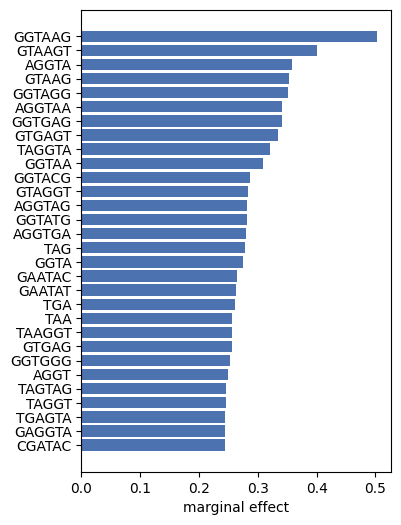

In [12]:
plt.figure(figsize=(4, 6))
plot_top_motifs(records, top=30)